In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import SelfTrainingClassifier

In [8]:
rng = np.random.default_rng(42)
rng_random = np.random.default_rng(123)
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "breast_cancer_dataset" / "data.csv"
df = pd.read_csv(train_path)
X = df.drop(columns=["id", "diagnosis", "Unnamed: 32"], errors="ignore")
y = (df["diagnosis"] == "M").astype(int).to_numpy()

In [9]:
# The outer test set stays untouched until the label-acquisition policy is finished.
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_pool, X_val, y_pool, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=7, stratify=y_dev
)
X_pool = X_pool.reset_index(drop=True)
y_pool = np.asarray(y_pool)

In [10]:
# ----- Semi-supervised self-training -----
# Pretend only 30% of the pool labels are initially available.
y_partial = y_pool.copy()
hide = rng.random(len(y_partial)) < 0.70
y_partial[hide] = -1

semi = Pipeline([
    ("scale", StandardScaler()),
    ("model", SelfTrainingClassifier(
        LogisticRegression(max_iter=2000), threshold=0.90
    )),
])
semi.fit(X_pool, y_partial)
print("self-training validation accuracy:",
      round(accuracy_score(y_val, semi.predict(X_val)), 3))

self-training validation accuracy: 0.963


In [11]:
# ----- Active-learning simulation -----
# Start from the same small class-balanced labeled set for both policies.
class0 = np.where(y_pool == 0)[0]
class1 = np.where(y_pool == 1)[0]
initial = np.concatenate([
    rng.choice(class0, size=20, replace=False),
    rng.choice(class1, size=20, replace=False),
])
active_labeled = set(initial.tolist())
random_labeled = set(initial.tolist())

label_counts = []
active_val_scores = []
random_val_scores = []
query_batch = 15
rounds = 8

def make_model():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000)),
    ])

for round_no in range(rounds):
    active_idx = np.array(sorted(active_labeled))
    random_idx = np.array(sorted(random_labeled))

    active = make_model()
    random_model = make_model()
    active.fit(X_pool.iloc[active_idx], y_pool[active_idx])
    random_model.fit(X_pool.iloc[random_idx], y_pool[random_idx])

    active_score = accuracy_score(y_val, active.predict(X_val))
    random_score = accuracy_score(y_val, random_model.predict(X_val))
    label_counts.append(len(active_labeled))
    active_val_scores.append(active_score)
    random_val_scores.append(random_score)
    print(
        f"round {round_no + 1}: labels={len(active_labeled)}, "
        f"active_val={active_score:.3f}, random_val={random_score:.3f}"
    )

    if round_no == rounds - 1:
        break

    # Uncertainty sampling: ask for labels closest to probability 0.5.
    active_unlabeled = np.array([
        i for i in range(len(X_pool)) if i not in active_labeled
    ])
    prob = active.predict_proba(X_pool.iloc[active_unlabeled])[:, 1]
    uncertainty = np.abs(prob - 0.5)
    active_query = active_unlabeled[np.argsort(uncertainty)[:query_batch]]
    active_labeled.update(active_query.tolist())

    # Same label budget, but query randomly as a baseline policy.
    random_unlabeled = np.array([
        i for i in range(len(X_pool)) if i not in random_labeled
    ])
    random_query = rng_random.choice(
        random_unlabeled, size=query_batch, replace=False
    )
    random_labeled.update(random_query.tolist())

round 1: labels=40, active_val=0.944, random_val=0.944
round 2: labels=55, active_val=0.925, random_val=0.953
round 3: labels=70, active_val=0.981, random_val=0.963
round 4: labels=85, active_val=0.953, random_val=0.963
round 5: labels=100, active_val=0.953, random_val=0.953
round 6: labels=115, active_val=0.953, random_val=0.953
round 7: labels=130, active_val=0.953, random_val=0.963
round 8: labels=145, active_val=0.953, random_val=0.963


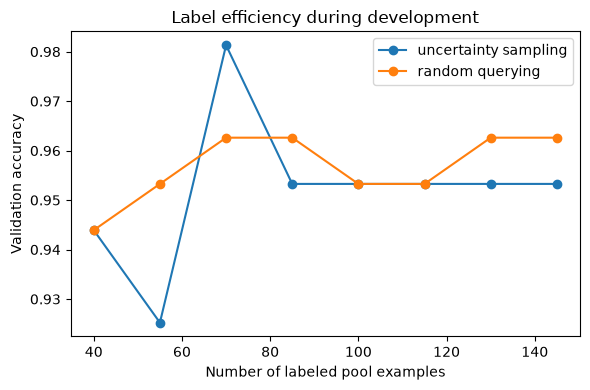

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(label_counts, active_val_scores, marker="o", label="uncertainty sampling")
plt.plot(label_counts, random_val_scores, marker="o", label="random querying")
plt.xlabel("Number of labeled pool examples")
plt.ylabel("Validation accuracy")
plt.title("Label efficiency during development")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# The acquisition policy is now locked. Evaluate each final model on test once.
active_final_idx = np.array(sorted(active_labeled))
random_final_idx = np.array(sorted(random_labeled))
active_final = make_model()
random_final = make_model()
active_final.fit(X_pool.iloc[active_final_idx], y_pool[active_final_idx])
random_final.fit(X_pool.iloc[random_final_idx], y_pool[random_final_idx])
print("final active-learning test accuracy:",
      round(accuracy_score(y_test, active_final.predict(X_test)), 3))
print("final random-query test accuracy:",
      round(accuracy_score(y_test, random_final.predict(X_test)), 3))

final active-learning test accuracy: 0.972
final random-query test accuracy: 0.972
